# GP Explorer — *SWAG-P* Simulation Toolkit

> **GP Explorer** is an interactive dashboard for designing, simulating,  
> optimising, and benchmarking **gap-plasmon resonators (GPRs)**.  
> No coding skills or deep RCWA knowledge required.

<details>
<summary>📘 Instructions (click to open it)</summary>

### Key features

| 🛠️ **Design** | 🔍 **Analyse** | ⚙️ **Optimise** | 📊 **Compare / Export** |
|---------------|---------------|----------------|-------------------------|
| • Build multilayer stacks (metal, dielectric, grating, spacer).<br>• Real-time sliders for every geometric parameter; live schematic updates. | • Compute reflectance spectra $R_\text{up}$ & $R_\text{down}$ on the fly.<br>• Extract resonant dips, FWHM, Q-factor, absorption. | • **Differential-Evolution algorithm** to maximise:<br> $\Delta R / \Delta n$ (intensity sensitivity) <br>• Boundaries, population, and Budgetfully configurable. | • Track peak shift vs. refractive-index change $\Delta n$.<br>• Export PNG figures, TXT summaries, or full HDF5 datasets for batch processing. |

---

### Typical workflow

1. **Select a template**  
   (metal/dielectric stack, grating order, period…).
2. **Tune the geometry** with the sliders — schematic and spectrum update instantly.
3. **Select the materials** from RefractiveIndex.INFO database.
4. **Apply a refractive-index offset** to layer and observe the peak shift $\Delta\lambda$.
4. **Run the simulation or optimiser**: choose lambda range, bounds, population size; best geometry updates live.
5. **Save / export** figures or full HDF5 data for post-processing.

---

### Why use GP Explorer ?

* **Zero code barrier** – ideal for rapid parametric scans or teaching.  
* **Physically rigorous** – RCWA computation validated against literature benchmarks.  
* **Fully reproducible** – every run (inputs + outputs) is logged for later reuse.

---
</details>

<details>
<summary>📘 State of the Art & Context</summary>

## 1&nbsp;· State of the Art & Context

*This project stems from my Master-2 internship (IM2NP, Marseille) and belongs to the **SWAG-P — Sensing With A Gap-Plasmon** ANR funding proposed and supported by [Pr. Moreau](http://cloud.ip.univ-bpclermont.fr/~moreau/), whose goal is to provide
ASSURED¹ biosensors for early-stage epidemic monitoring.*

---

### Gap-Plasmon Resonator (GPR) concept

|  |  |
|--|--|
| **Geometry** | A metallic nanocube (“nano-patch antenna”) sits on a nanometric dielectric spacer covering an ultrathin gold mirror.<br>Layers (bottom→top): substrate · Au mirror · spacer · Ag nanocube. |
| **Physics**  | Light is trapped in the gap; the magnetic field bounces between cube edges, forming a cavity of length *L* → high effective index → extreme field confinement. |
| **Sensing**  | A tiny refractive-index change&nbsp;$\Delta n$ in the gap shifts the resonance wavelength&nbsp;$\lambda\_0$; this shift is read out in reflection. |

---

> Designed to satisfy the ASSURED¹ guidelines, each sensor is a metallic nanocube (“nano-patch antennas”) resting on a dielectric spacer deposited over a functionalizable ultrathin gold film (Fig. 1 a).

<!-- illustration -->
<p align="center">
  <img src="../docs/assets/GPR_-min.png" alt="Gap-plasmon geometry" width="900">
</p>

---

### Why GPR instead of planar SPR ?

| Limitation of conventional SPR | Advantage of GPR |
|--------------------------------|------------------|
| Evanescent field extends > 100 nm → limited spatial resolution. | Field is highly confined in a tiny nanometer gap → surface-bound biomolecules induce a large optical perturbation. |
| Effective index of the mode is modest (≈2). | Effective index can exceed 5 → sensitivity **enhance**. |

---

### Role of **GP Explorer**

The present software:

* **Generates** reflectance spectra via RCWA for arbitrary GPR geometries.  
* **Quantifies** spectral dip position, FWHM, Q-factor, sensitivity: $\Delta R/\Delta n$.  
* **Optimises** the architecture with a Differential-Evolution algorithm to maximise sensitivity.  
* **Outputs** PNG, TXT and HDF5 files for reproducibility and downstream analysis.

---

<small>¹ ASSURED = Affordable • Sensitive • Specific • User-friendly • Rapid/Robust • Equipment-free • Deliverable.</small>

</details>

In [1]:
from gap_plasmon_2d import paths
### INITIALIZATION SCRIPT
# This script is executed at the beginning to set up the environment.
# It ensures that the notebook is trusted, detects the project root, and adds necessary directories to the PYTHONPATH.
# It also defines shared paths for the workspace, notebooks, summary, experimental data, and combined materials JSON file.

import sys, subprocess
from pathlib import Path


# 1) Trust this notebook (silencieusement si ça échoue)
nb = Path().resolve()
try:
    subprocess.run(
        [sys.executable, "-m", "jupyter", "trust", str(nb)],
        check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )
except Exception:
    pass  # no worries if trust fails

# 2) Détecter racine du projet (parent contenant "modules" et "data")
cwd = Path().resolve()
project_root = cwd
for p in [cwd] + list(cwd.parents):
    if (p / "modules").is_dir() and (p / "data").is_dir():
        project_root = p
        
        break

# 3) Ajouter au PYTHONPATH les dossiers utiles s’ils existent
for folder in ("modules", "tools", str(paths.RESULTS_DIR)):
    d = project_root / folder
    if d.is_dir():
        sys.path.insert(0, str(d))

# 4) Définir les chemins partagés
workspace_dir      = project_root
notebooks_dir      = project_root / str(paths.RESULTS_DIR)
summary_dir        = notebooks_dir / "summary_simulation"
exp_data_dir       = notebooks_dir / "Experimental_Data"
data_dir           = project_root / "data"
json_combined_path = data_dir / "combined_materials.json"

<details>
<summary>📘 Designing the Geometry </summary>

## 2 · Designing the Geometry

GP Explorer provides a **live schematic** of the gap-plasmon resonator (GPR).
Every time you move a slider the drawing updates, so you always see how the
stack evolves before running a single simulation.

---

### Quick start 🔧

1. **Load a template** (menu *Pre-configurations*).  
   It contains the “classical” dimensions used in literature.
2. **Inspect** the live drawing — hover a layer to show its thickness.
3. **Tune the parameters** (cube size, spacer thickness, grating period, …).  
   The schematic scales automatically.
4. **Name your geometry** in the *Configuration name* field.
5. Click **`Add configuration`**.  
   Repeat steps 3-5 to build a batch of geometries.
6. When done, click **`Save & Quit`**  ➜ JSON stored in `configs/geom_mat_combinations.json`.

> **Tip :** You may reload a saved geometry, change a few numbers, then press
> **`Update`**. Use **`Delete`** to remove unwanted entries.

---

### Visual conventions

* **Hatching** on the substrate and superstrate indicates that those layers
  extend far beyond the drawn window (thickness not to scale).  
* Thicknesses differ by orders of magnitude; the schematic applies a *logarithmic
  stretch* so that every layer remains visible.

---

### Two emblematic cases

| Case | Description | Impact on spectrum |
|------|-------------|--------------------|
| **A – Structure 1** | Nanocube sidewalls **fully exposed** to the external medium (superstrate). | Resonant mode samples mostly the superstrate; high sensitivity to bulk $\Delta n$. |
| **B – Structure 2** | Dielectric + Functionalisation + Molecule layers **wider than the cube**; sidewalls are partly embedded. | Mode confined closer to the functional layer; stronger response to surface-bound molecules. |

Design both variants, save them, then move on to the **Material Selector** to
assign optical constants before launching the simulation.

</details>


In [4]:
# %% Cellule 2 – Geometry settings
from gap_plasmon_2d.ui.geometry_settings import create_geometry_widget

# Issues with values input directly in the widget
# Affichage du widget de configuration de la géométrie
geometry_widget = create_geometry_widget()
display(geometry_widget)

<details>
<summary>📘 Selecting the Materials </summary>

## 3 · Selecting the Materials

Every layer of the geometry defined in **Step&nbsp;2** must now be assigned a
**complex permittivity** $\tilde{\varepsilon}(\lambda)$.
GP Explorer offers four selection modes — no sliders, just dropdown menus.

---

| Mode | When to use | What it does |
|------|-------------|--------------|
| **None** | must to be applied on abscent layer. | Nonetheless, note that **None** sets $\tilde{\varepsilon}=1$. So, you can select Air as None. |
| **Custom** | You have a specific refractive index $\tilde{n}=n+ik$ not in the databases. | It is for permitivitie, so enter either $\tilde{n}^2$ **or** $\tilde{\varepsilon}$.<br>Remember: $\tilde{\varepsilon} = \tilde{n}^{\,2} \qquad (\mu_r = 1)$ |
| **Standard** | Common metals & dielectrics curated by [*Pr. Moreau*](https://github.com/AnMoreau/PyMoosh/blob/stable/PyMoosh/models.py) and [*Dr. Bennett*](https://github.com/Ellawin/swag/blob/master/RCWA2D). | Pick directly from a short, vetted list (Au, Ag, SiO₂, TiO₂, …). |
| **RefractiveIndex.info** | You need exotic or wavelength-dependent data. | Browse **Shelf → Book → Page** to import any dataset from [M. Polyanskiy’s online database](https://github.com/polyanskiy/refractiveindex.info-database/tree/master/database/data) [^2]. |

---

### Workflow

1. **Choose a layer** in the upper panel. 
2. **Select** the material of interest.
3. **Repeat** for every layer of interest previously defines (thickness =! 0nm). 
4. **Name** your material configuration; then press **`Save & Quit`** to lock the material stack.

> **Tip — Custom values:** if you know only the real part of the index, set  
> $k=0$; the solver accepts purely real $\tilde{n}$.

---

### References  

[^2]: M. Polyanskiy,  **RefractiveIndex.info** database (https://refractiveindex.info).


</details>


In [ ]:
from gap_plasmon_2d.ui.material_selector import MaterialSelectorTabbedNotebook, DEFAULT_ROLES

# Instanciation et affichage du sélecteur dans le Notebook
selector = MaterialSelectorTabbedNotebook(DEFAULT_ROLES)
selector.display()

<details>
<summary>📘 Validity of optical data & wavelength range </summary>

### Validity of optical data & wavelength range

Every material in GP Explorer is described by a wavelength-dependent dataset
$\tilde{\varepsilon}(\lambda)$ (or $\tilde{n}(\lambda)$) obtained from:

* analytical **models** (Drude–Lorentz, Sellmeier, Cauchy, …), or  
* **interpolated** experimental points.

Each dataset is valid **only within its own spectral range**.  
For a simulation to be meaningful, **all selected materials must share a common
interval that fully contains your simulation range**.

| What GP Explorer does | How it looks in the GUI |
|-----------------------|-------------------------|
| • Lists every material with its **min / max wavelength**. | Shown next to the material name (e.g. “Au | 400–2000 nm”). |
| • Checks overlap when you press **`Run`**. | If any layer falls outside its validity window, a red warning appears and the simulation is blocked. |
| • Allows manual adjustment for interpolated datasets. | Enter custom “λ min / λ max” in the *Advanced* panel if you trust extrapolated data. |
| • Plots $n(\lambda)$, $k(\lambda)$ or $\Re[\tilde{\varepsilon}]$, $\Im[\tilde{\varepsilon}]$ for all selected models. | Click **`Plot indices`** for an instant comparison of competing models. |

---

### Manage material configurations

* **Add / Delete / Load / Update** work exactly like in the Geometry panel.  
* Two presets are shipped: **S1** (cube sidewalls exposed) and **S2**
  (cube partially embedded). Feel free to modify or remove them.  
* Finish with **`Save & Quit`** to store the stack in  
  `configs/material_config.json`.

  </details>

In [ ]:
from gap_plasmon_2d.materials.geometry__material__config import create_geometry_material_widget
w = create_geometry_material_widget()
display(w)

<details>
<summary>📘 Combine geometry × material stacks </summary>

---

### Combine geometry × material stacks

Once both panels are saved, open **“Combine Configurations”**:

| Step | Action |
|------|--------|
| 1 | Choose a *Geometry configuration* (e.g. “GPR_150nm_cube”). |
| 2 | Choose a *Material configuration* (e.g. “Gold_SiO2_Water”). |
| 3 | Press **`Add Row`** allows to combine several architectures at the same time. |
| 4 | Click **`Combine & Save`**  → a new entry appears in the list → file `configs/geom_mat_combinations.json` is updated. |

These combined configurations are the inputs used by the **Simulation** and
**Optimisation** tabs.

---
</details>

<details>
<summary>📘 Simulate, Plot, Validate & Optimise</summary>


## 4 · Simulate, Plot, Validate & Optimise

After pairing each **Geometry** with a **Material** stack, you can explore the
optical response in the **Simulation** and **Plots** tab, organised in four tabs:

| Tab | Purpose |
|-----|---------|
| **I · Simulation** | Compute and plot reflectance spectra for any saved configuration. |
| **II · Plot: Multi-spectra** | Overlay several spectra in a single figure + numerical summary. |
| **III · Validation** | Check the numerical accuracy (difference plots, convergence curves). |
| **IV · Optimisation** | Inverse-design the structure via a Differential-Evolution (DE) algorithm. |

---

### I · Simulation

* **Wavelength range** – set $\lambda_{min}$, $\lambda_{max}$ and **# points**  
  → defines the spectral resolution.
* **Convergence curves** – visualize reflectance at fixe wavelenght vs. number of modes to verify that the chosen harmonic count lies in the plateau region.
* **Fourier harmonics** – Then, selecte relevant number of RCWA modes for your computation. Found compromise between accuracy ↔ speed.  
  > Increasing the mode count past the convergence point can trigger numerical
  > noise (ill-conditioned matrices, round-off errors) and degrade results.
* **Outputs** – every run produces  
  * a downloading PNG figure (R\_up),  
  * a TXT summary, and  
  * an optional HDF5 entry (`simulation_results.h5`). All files are downloadable via the **Download** buttons.

---

### II · Plot: Multi-spectra

* Select any number of previous runs → GP Explorer draws them in one axis.  
* A table underneath lists key metrics for quick comparison  
  (FWHM, $\lambda_0$, $\Delta\lambda/\Delta n$, etc.).

---

### III · Validation

* **Difference plot** – choose two spectra computed with different settings and
  plot $|R_1 - R_2|$. A flat line around $10^{-8}$ confirms numerical convergence.

---

### IV · Optimisation (DE)

Inverse design: maximize the sensitivity of your GPR.

1. **In the Simulation tab**  
   * Select a configuration + the layer affected by $\Delta n$.  
   * Choose the mode strategy (*fixed*, *custom*, or *auto*).  
   * Enter the target wavelength for the cost function defined as $1-Sensitivity$
2. **Open the Optimisation tab**  
   * Tick the layer thicknesses to optimise.  
   * Adjust DE parameters (population, iterations, bounds) if needed.  
   * Launch **`Run optimisation`** – the best geometry updates live; results are
     stored alongside ordinary simulations.
3. **Plot** the corresponding convergence and confidence curve to confirme (or not) accurate results.
---

Once satisfied, export the optimised spectrum or the full HDF5 dataset for
further analysis.

---
</details>

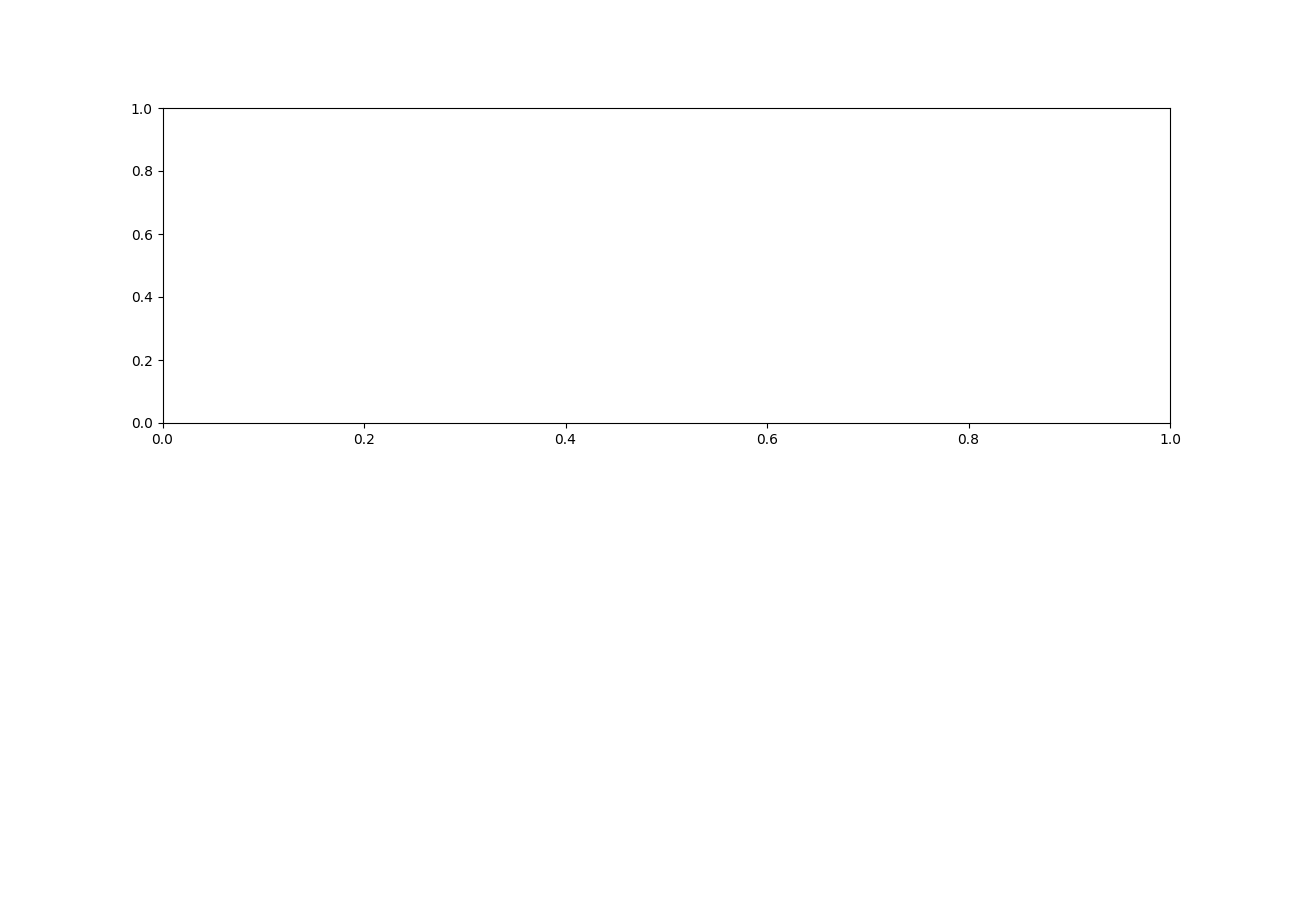

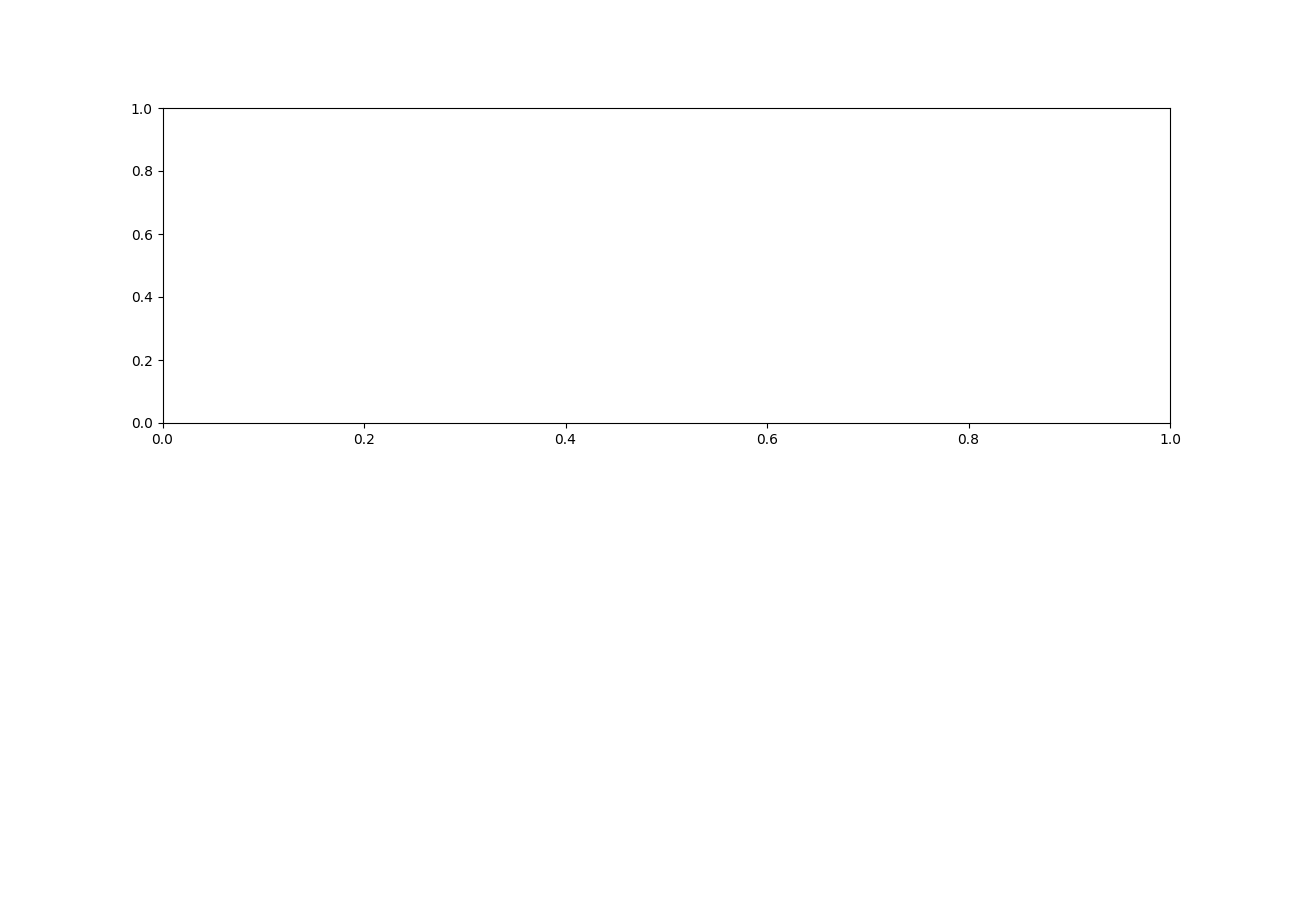

In [ ]:
%matplotlib widget

from gap_plasmon_2d.ui.interactive_simulation import create_advanced_app
from IPython.display import display

# Crée et affiche l'interface complète
app = create_advanced_app()
display(app)